In [120]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [122]:
conn = sqlite3.connect('../data/cleaned/sales_analysis.db')

In [ ]:

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

### 1. Which categories generate the highest sales and profit?

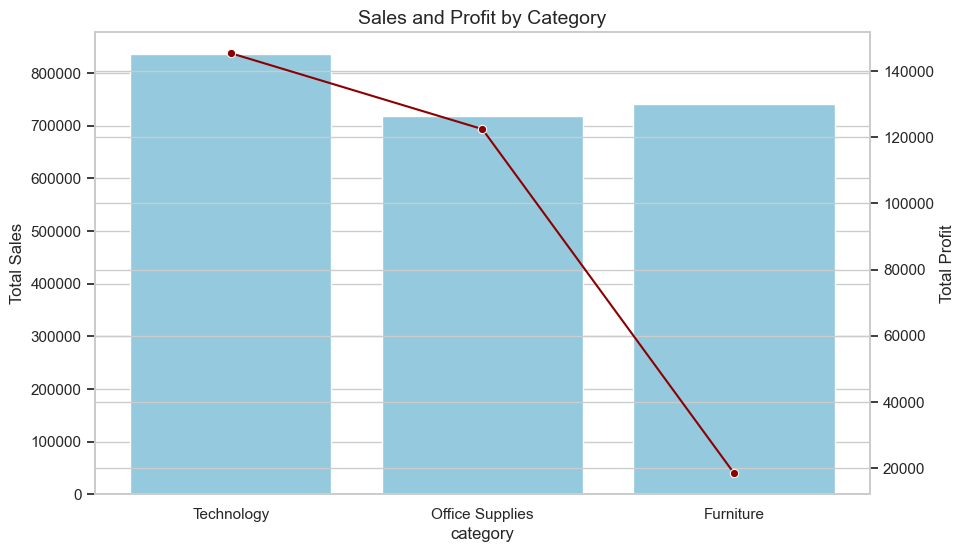

In [123]:
df_category = pd.read_sql("""
SELECT category,
       SUM(sales) AS total_sales,
       SUM(profit) AS total_profit
FROM sales
GROUP BY category
ORDER BY total_profit DESC;          
""", conn)

fig, ax1 = plt.subplots()

sns.barplot(data=df_category, x="category", y="total_sales", ax=ax1, color="skyblue")
ax1.set_title("Sales and Profit by Category")
ax1.set_ylabel("Total Sales")

# Secondary axis for profit
ax2 = ax1.twinx()
sns.lineplot(data=df_category, x="category", y="total_profit", ax=ax2, color="darkred", marker="o")
ax2.set_ylabel("Total Profit")
plt.savefig("../data/cleaned/outputs/charts/sales_profit_by_category.png", dpi=300, bbox_inches="tight")
plt.show()



### 2. Which region performs best

C:\Users\mohas\AppData\Local\Temp\ipykernel_32588\3513973901.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region_sorted, x="total_sales", y="region", palette="Blues_d")


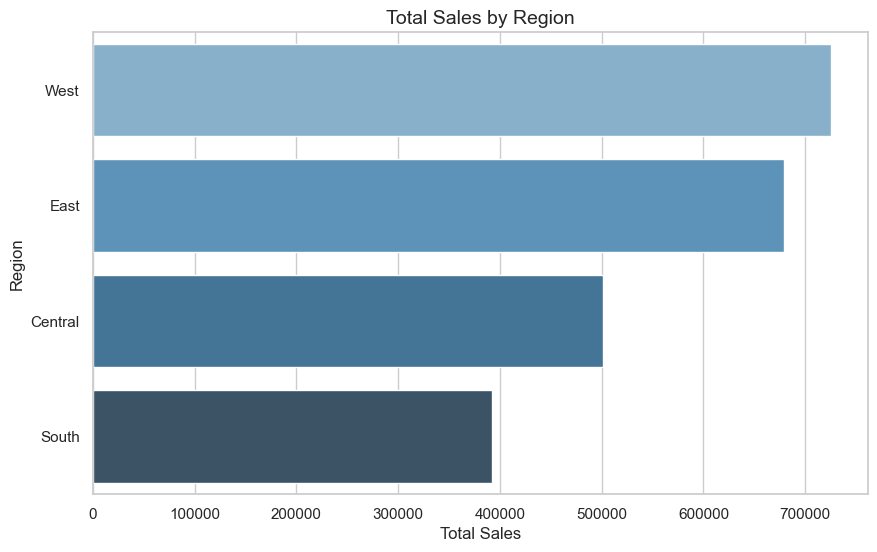

In [138]:
df_region = pd.read_sql("""
SELECT region,
       SUM(sales) AS total_sales,
       SUM(profit) AS total_profit
FROM sales
GROUP BY region
ORDER BY total_profit DESC;                 
""", conn)


sns.barplot(data=df_region_sorted, x="total_sales", y="region", palette="Blues_d")
plt.title("Total Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.savefig("../data/cleaned/outputs/charts/top_10_profitable_products.png", dpi=300, bbox_inches="tight")
plt.show()

### 3. Which products are most profitable?

C:\Users\mohas\AppData\Local\Temp\ipykernel_32588\2500649591.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


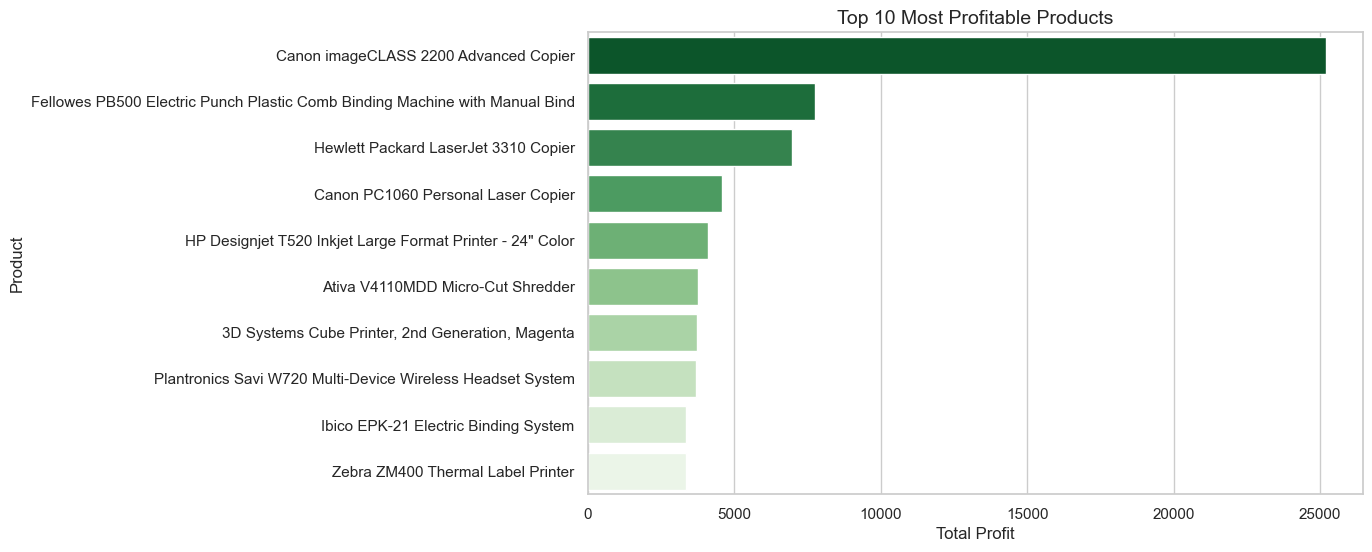

In [125]:
df_products = pd.read_sql("""
SELECT Product_Name,
       ROUND(SUM(Profit), 2) AS total_profit
FROM sales
GROUP BY Product_Name
ORDER BY total_profit DESC
LIMIT 10;                
""", conn)

sns.barplot(
    data=df_products,
    x="total_profit",
    y="product_name",
    palette="Greens_r"
)

plt.title("Top 10 Most Profitable Products")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.savefig("../data/cleaned/outputs/charts/sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### 4. How do sales change over time?

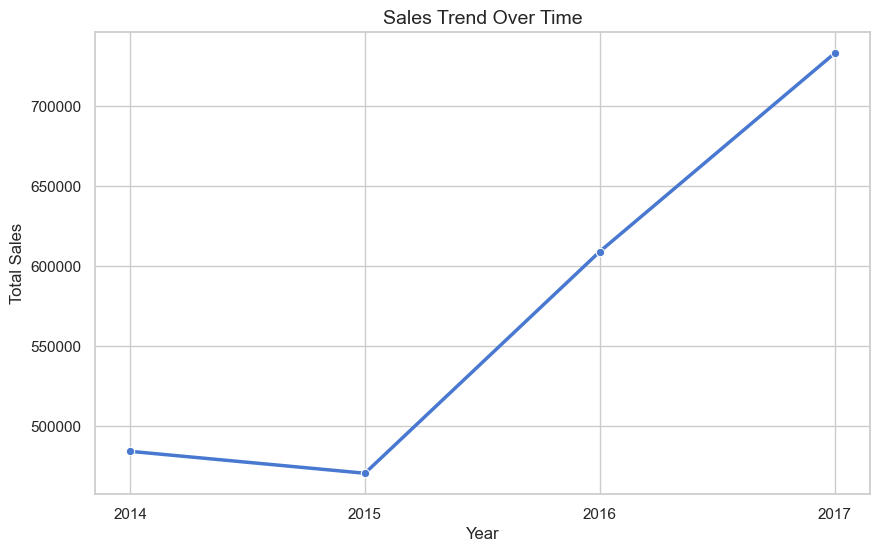

In [143]:
df_time = pd.read_sql("""
SELECT order_year,
       ROUND(SUM(Sales), 2) AS total_sales
FROM sales
GROUP BY Order_year
ORDER BY Order_year;                
""", conn)

sns.lineplot(data=df_time, x="order_year", y="total_sales", marker="o", linewidth=2.5)
plt.xticks(df_time['order_year'])
plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.savefig("../data/cleaned/outputs/charts/sales_trend_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

### 5. What is the effect of discounts on profit?

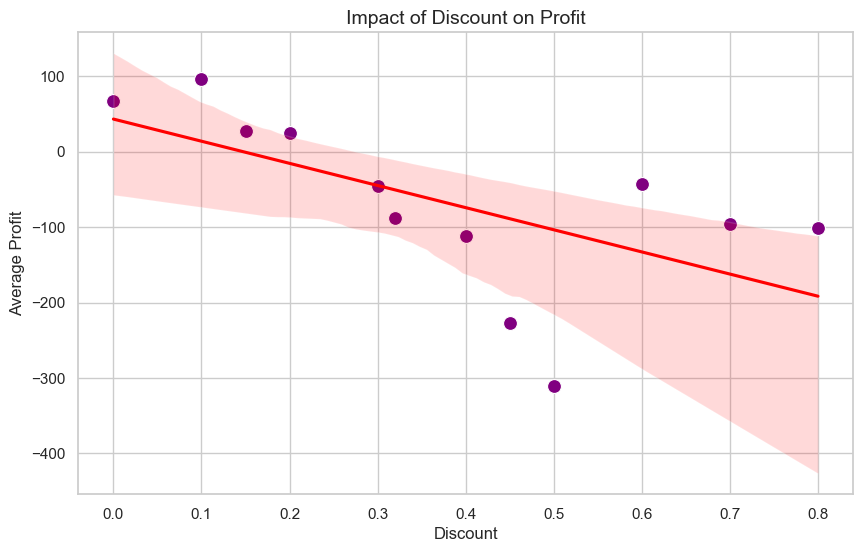

In [145]:
df_discount = pd.read_sql("""
SELECT discount,
       AVG(profit) AS avg_profit
FROM sales
GROUP BY discount
ORDER BY discount;                 
""", conn)

sns.scatterplot(data=df_discount, x="discount", y="avg_profit", s=100, color="purple")

sns.regplot(
    data=df_discount,
    x="discount",
    y="avg_profit",
    scatter=False,
    color="red"
)

plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.savefig("../data/cleaned/outputs/charts/discount_vs_profit.png", dpi=300, bbox_inches="tight")
plt.show()

### 6. Which customer segments contribute most to revenue?

C:\Users\mohas\AppData\Local\Temp\ipykernel_32588\2246886342.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segment, x="segment", y="total_sales", palette="Set2")


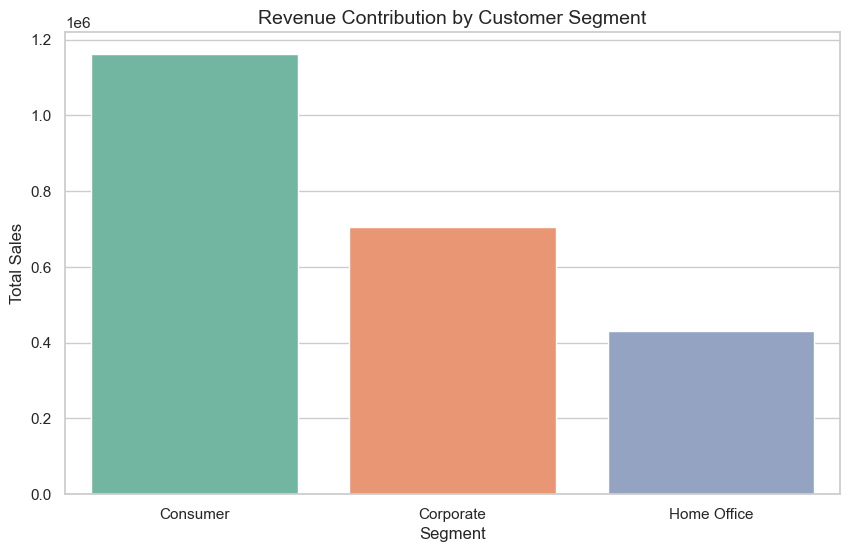

In [136]:
df_segment = pd.read_sql("""
SELECT segment,
       SUM(sales) AS total_sales
FROM sales
GROUP BY Segment
ORDER BY total_sales DESC;              
""", conn)

sns.barplot(data=df_segment, x="segment", y="total_sales", palette="Set2")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.savefig("../data/cleaned/outputs/charts/customer_segments_contributions.png", dpi=300, bbox_inches="tight")
plt.show()